# Normalizing Flows
> For the Fall 2024 course: *Machine Learning in Physics*<br>
> Created: Aug. 14, 2024 Harrison B. Prosper

## Introduction
Let $p(x)$ and $q(y)$ be probability densities, where $x, y \in \mathbb{R}^d$, then the following necessarily holds 
\begin{align}
    p(x) dx & = q(y) dy .
\end{align}
Given a **bijection** $f : x \rightarrow y$, that is, a one-to-one invertible function, which we'll write as $y = f(x)$, then
\begin{align}
    p(x) & = q(y) \left| \text{det} \, \nabla_x f  \right| , \text{ or, equivalently, }\\
    \log p(x) & = \log q(y) + \log \left |\text{det} \, J \right|,
\end{align}
where $J = \nabla_x f$ is the Jacobian maxtrix of the transformation $y = f(x)$. **Normalizing flows**[1] are a set of methods that model the function $y = f(x)$ as a composition
\begin{align}
    f & = f_n \circ f_{n-1} \circ \cdots f_2 \circ f_1, 
\end{align}
of functions $f_i$, $i =1,\cdots, n$, which can expressed recursively as
\begin{align}
        y_{n}  & = f_{n}(y_{n-1}), \quad y_n \equiv y, \\
        y_{n-1}  & = f_{n-1}(y_{n-2}), \\
             & \vdots \\
        y_1  & = f_1(y_0), \quad y_0 \equiv x .
\end{align}
The bijection $f$ can be conceptualized as a "flow" from the point $x$ to the point $y$ in $\mathbb{R}^d$.
Noting that $\text{det} \, J = \prod_{i=1}^n \text{det} \, J_i $, where $J_i$ is the Jacobian of the transformation $y_i = f_i(y_{i-1})$, and defining $y_n \equiv y$ and $y_0 \equiv x$, we can write 
\begin{align}
    p(x) & = q(y) \left| \text{det} \, J \right| , \text{ or, equivalently, }\\
    \log p(x) & = \log q(y) + \sum_{i=1}^n \log \left |\text{det} \, J_i \right| .
\end{align}
The key to mapping from $\log q(y)$ to $\log p(x)$ is computing the sequence of Jacobian determinants. Usually, $q(y)$ is taken to be a diagonal $d$-dimensional, zero mean, unit variance normal, hence the moniker "normalizing" flow.

## Real-valued Non-volume Preserving Flows (R-NVP)

Many proposals exist for normalizing flows. In this tutorial, we implement the flow introduced by Dinh *et al*.[2]. For a given function $f_i$, let $x \in \mathbb{R}^d$ be a point in the domain of $f_i$ and $y \in \mathbb{R}^d$ be a point in its codomain, which, because $f_i$ is bijective, coincides with the image of $f_i$. This is just a mathy way of saying that $y = f_i(x)$ such that for every $x$ there is a single $y$ and for every $y$ there is a single $x$. 

The key and clever innovation [2] is to split the vector $x$ into two sub-vectors $x_A = (x_1, \cdots, x_m)$ and $x_B = (x_{m+1},\cdots, x_d)$ of dimensions $m$ and $d-m$, respectively, and do likewise for $y$, which is split into the vectors $y_A$ and $y_B$. The components, $f_{i, j}(x)$, of the $d$-dimensional function $f_i$ are given by
\begin{align}
f_{i, j}(x) &= 
     \begin{cases}
        x_j             & j = 1, \cdots, m, \\
        x_j \exp[s_{j-m}(x_1,\cdots,x_m)] + t_{j-m}(x_1,\cdots,x_m) &  j = m+1, \cdots, d .     
    \end{cases} 
\end{align}
The above can be written compactly as
\begin{align}
    y_A & = x_A, \\
    y_B & = x_B \odot \exp[s(x_A)] + t(x_A),
\end{align}
where $\odot$ denotes the Hadamard product [3], that is, an elementwise product, and where it is understood that $\exp(*)$ is also applied elementwise, that is, $\exp(s(x_A))$ is a vector with components $\exp[s_1(x_A)]$, $\cdots$, $\exp[s_{d-m}(x_A)]$ and $s, t : \mathbb{R}^m \rightarrow \mathbb{R}^{d-m}$ are functions to be determined.

The form of $f_i$ is chosen to render its inverse $f_i^{-1}$ is easy to compute,
\begin{align}
    x_A & = y_A, \\
    x_B & = [y_B - t(y_A)] \odot \exp[-s(y_A)] ,
\end{align}
as well as its Jacobian,
\begin{align}
    J_i = \begin{pmatrix}
            \mathbb{1} & \mathbb{0} \\
            \nabla_{x_A} y_B  &  \exp[s(x_A)]
        \end{pmatrix} ,
\end{align}
which yields an easily computed log determinant, 
\begin{align}
\log|\text{det} \, J_i| & = \sum_{j=1}^{d-m} s_j(x_A) .
\end{align}
Since the calculations of $f_i^{-1}$ and $\log |\text{det} \, J_i|$ do not depend on the details of the functions $s(x_A)$ and $t(x_A)$, the latter can be arbitrarily complicated; for example, they can be modeled with deep neural networks.

## Tutorial
In this tutorial, we use a normalizing flow to map between a 2D spiral distribution and a 2D, zero mean, unit variance normal. The tutorial is inspired by the blogs of Sebastian Callh[4],
Brennan Gebotys[5], and the excellent course by François Fleuret[6]. We largely follow the notation of the original paper by Dinh *et al*.[2].


## References
  1. Danilo Jimenez Rezende, and Shakir Mohamed, *Variational Inference with Normalizing Flows*, https://arxiv.org/abs/1505.05770
  2. Laurent Dinh, Jascha Sohl-Dickstein, and Samy Bengio, *Density Estimation using Real NVP*, https://arxiv.org/abs/1605.08803
  3. https://en.wikipedia.org/wiki/Hadamard_product_(matrices)
  4. https://sebastiancallh.github.io/post/affine-normalizing-flows/
  5. https://gebob19.github.io/normalizing-flows/
  6. https://fleuret.org/dlc/


## Running on Google Colab
If on Google Colab (https://colab.research.google.com), execute cell below.

In [1]:
try:
    import google.colab
    url = f"https://raw.githubusercontent.com/hbprosper/mlinphysics/refs/heads/main"
    !wget -q {url}/clone2colab.ipynb -O clone2colab.ipynb
    %run clone2colab.ipynb
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [3]:
import os, sys

import numpy as np
import pandas as pd
import scipy.stats as st

import matplotlib as mp
import matplotlib.pyplot as plt

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn
from torch.distributions.multivariate_normal import MultivariateNormal

# module to access data in Hierarchical Data Format (HDF or H5 format)
import h5py

import shutil
import importlib

# ML in physics module
import mlinphysics.nn as mlp
import mlinphysics.utils.data as dat
import mlinphysics.utils.monitor as mon

# update fonts
if not IN_COLAB:
    plt.rcParams.update({
      "text.usetex": shutil.which('latex') is not None,
      "font.family": "sans-serif",
      "font.sans-serif": "Helvetica",
      "font.size": 14
  })

## Computational device

In [4]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n\tComputational device: {str(DEVICE):4s}\n')


	Computational device: cpu 



## Load Data

In [5]:
def load_data(filename='../data/spiral.h5'):
    f = h5py.File(filename, "r")
    return np.array(f['X0'])

X0 = load_data().astype(np.float32) # default bit-size for PyTorch floats
X0.shape, X0.dtype

((100000, 2), dtype('float32'))

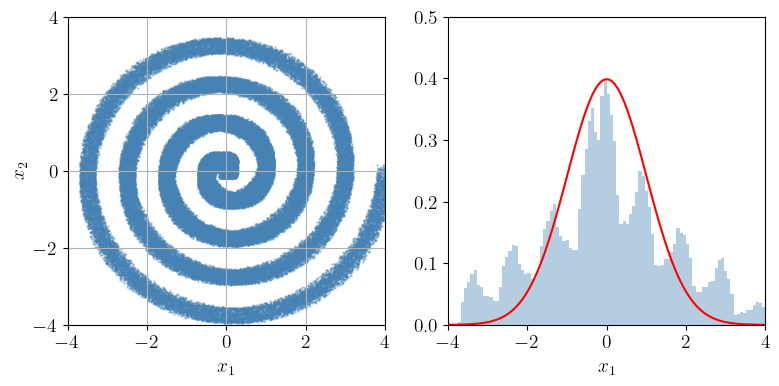

In [6]:
def plot_data(d, xmin=-4, xmax=4, ymin=-4, ymax=4, filename='fig_spiral.png'):

    x1, x2 = d[:, 0], d[:, 1]
    
    fig = plt.figure(figsize=(9, 4))
    fig.tight_layout()
    
    ax  = fig.add_subplot(1, 2, 1)
    
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel(r'$x_1$')
    
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel(r'$x_2$')
    
    ax.scatter(x1, x2, s=0.5, color='steelblue', alpha=0.4)

    ax.grid('both')

    ax2  = fig.add_subplot(1, 2, 2)
    ax2.set_xlim(xmin, xmax)
    ax2.set_xlabel(r'$x_1$')
    ax2.set_ylim(0, 0.5)
    
    c, x, _ = ax2.hist(x1, range=(xmin, xmax), bins=100, density=True, 
                       color='steelblue', alpha=0.4)
    x = (x[1:]+x[:-1])/2
    h = x[1]-x[0]
    y = st.norm.pdf(x)
    ax2.plot(x, y, color='red')
    
    if filename:
        plt.savefig(filename)
        
    plt.show()

plot_data(X0)

## Configuration

In [36]:
# name of model
# -----------------------------------------
name = 'normflow'

# choose whether to create or load a configuration file
load_existing_config = False

if load_existing_config:
    config = mlp.Config(f'{name}.yaml')
else:
    # create new configuration
    config = mlp.Config(name, dirname='test')

    # training configuration
    # -----------------------------------------
    ndata = len(X0)
    train_size = int(0.75*ndata)
    test_size  = int(0.20*ndata)
    val_size   = ndata - train_size - test_size
    
    config('train_size', train_size)  # training sample size
    config('test_size',   test_size)  # test sample size
    config('val_size',     val_size)  # validation sample size
    
    config('batch_size',     32)  # must be one!
    config('monitor_step',  100)  # monitor training every n (=10) iterations
    config('delete', True)        # delete losses file before training, if True
    config('frac', 0.015)         # save model if average loss decreases by more
                                  # than frac percent

    # optimizer / scheduler configuration
    # -----------------------------------------
    # a step comprises a given number of iterations
    config('n_steps', 3)                # number of training steps
    config('n_iters_per_step', 200_000)
    config('base_lr', 1.e-4)            # initial learning rate
    config('gamma', 0.8)                # learning rate scale factor
    print(f'\nSave configuration to file {config.cfg_filename}\n')

    config.save()

# add number of iterations
config('n_iterations',
       config('n_iters_per_step') * \
       config('n_steps'))

print(config)


Save configuration to file runs/test/normflow_config.yaml

name: normflow
file:
  losses: runs/test/normflow_losses.csv
  params: runs/test/normflow_params.pth
  init_params: runs/test/normflow_init_params.pth
  plots: runs/test/normflow_plots.png
train_size: 75000
test_size: 20000
val_size: 5000
batch_size: 32
monitor_step: 100
delete: true
frac: 0.015
n_steps: 3
n_iters_per_step: 200000
base_lr: 0.0001
gamma: 0.8
n_iterations: 600000



## Train, validation, and test sets
There is some confusion in terminology regarding validation and test samples (or sets). We shall adhere to the defintions given here https://machinelearningmastery.com/difference-test-validation-datasets/):
   
  * __Training Dataset__: The sample of data used to fit the model.
  * __Validation Dataset__: The sample of data used to decide 1) whether the fit is reasonable (e.g., the model has not been overfitted), 2) decide which of several models is the best and 3) tune model hyperparameters.
  * __Test Dataset__: The sample of data used to provide an unbiased evaluation of the fitted model.

The validation set will be some small fraction of the training set and will be used to decide when to stop the training.

### Datasets

In [37]:
importlib.reload(dat)

train_size = config('train_size')
val_size   = config('val_size')
test_size  = config('test_size')

# training dataset (this defines the empirical risk to be minimized)
print('training data')
train_data = dat.Dataset(X0,
                         start=0,
                         end=train_size)

# a random subset of the training data to check for overtraining
# by comparing with the empirical risk from the validation set
print('training data for validation')
train_data_val = dat.Dataset(X0,
                             start=0,
                             end=train_size,
                             random_sample_size=val_size)

# validation dataset (for monitoring training)
print('validation data')
val_data = dat.Dataset(X0,
                       start=train_size,
                       end=train_size + val_size)

# test dataset
print('test data')
test_data= dat.Dataset(X0,
                       start=train_size + val_size,
                       end=train_size + val_size + test_size)

training data
Dataset
  shape of x: torch.Size([75000, 2])

training data for validation
Dataset
  shape of x: torch.Size([5000, 2])

validation data
Dataset
  shape of x: torch.Size([5000, 2])

test data
Dataset
  shape of x: torch.Size([20000, 2])



### DataLoaders

In [38]:
print('train data loader')
train_loader = dat.DataLoader(train_data, 
                              batch_size=config('batch_size'),
                              num_iterations=config('n_iterations'))

print('train data loader for validation')
train_loader_val = dat.DataLoader(train_data_val, batch_size=len(train_data_val))

print('validation data loader')
val_loader = dat.DataLoader(val_data, batch_size=len(val_data))

print('test data loader')
test_loader = dat.DataLoader(test_data, batch_size=len(test_data))

train data loader
DataLoader
  Number of iterations has been specified
  maxiter:          600000
  batch_size:           32
  shuffle_step:       2343

train data loader for validation
DataLoader
  maxiter:               1
  batch_size:         5000
  shuffle_step:          1

validation data loader
DataLoader
  maxiter:               1
  batch_size:         5000
  shuffle_step:          1

test data loader
DataLoader
  maxiter:               1
  batch_size:        20000
  shuffle_step:          1



## Build Model
### Bijection
\begin{align}
\boldsymbol{y  = f(x)}\\
    y_A &= x_A, \\
    y_B & = x_B \odot \exp[s(x_A)] + t(x_A),\\ \\
\boldsymbol{x  = f^{-1}(y)}\\
    x_A & = y_A, \\
    x_B & = [y_B - t(y_A)] \odot \exp[-s(y_A)] , \\ \\
    \log p(x) & = \log q(y) + \sum_{i=1}^n \log \left |\text{det} \, J_i \right|, \quad \log \left |\text{det} \, J_i \right| = \sum_{j=1}^{d-m} s_j(x_A)  .
\end{align}

In [39]:
class Bijection(nn.Module):
    
    def __init__(self, in_features, 
                 n_width=16, n_hidden=1, f_hidden=mlp.Sin()):
        
        # remember to initialize base (that is, parent) class
        super().__init__()

        # We'll be splitting the columns of the input into two pieces
        # of size m and k = d - m columns, respectively.
        d = in_features   # dimension of vectors 
        m = d // 2        # size of the smaller chunk if d is odd          
        self.d = d
        self.m = m
        self.k = d - m
        
        n_input  = self.m
        n_output = self.k  # size of the larger chunk if d is odd

        # dim(inputs)  = m
        # dim(outputs) = d-m
        
        self.s = nn.Sequential(nn.Linear(n_input, n_width), f_hidden)
        for _ in range(n_hidden):
            self.s.append(mlp.ResNet(n_width, n_width))
            self.s.append(nn.LayerNorm(n_width))
        self.s.append(nn.Linear(n_width, n_output))

        self.t = nn.Sequential(nn.Linear(n_input, n_width), f_hidden)
        for _ in range(n_hidden):
            self.t.append(mlp.ResNet(n_width, n_width))
            self.t.append(nn.LayerNorm(n_width))
        self.t.append(nn.Linear(n_width, n_output))
     
    def forward(self, x):
        s = self.s
        t = self.t
        m = self.m
        k = self.k     # k = d - m
        
        # split columns
        xA, xB = x[:, :m], x[:, m:] 
        
        # compute s and t functions
        sB = s(xA)     # dim(sB) = d - m
        tB = t(xA)     # dim(tB) = d - m
        
        # torch_exp(*) is applied to s element-wise
        yA = xA
        yB = xB * torch.exp(sB) + tB

        # put pieces together
        y = torch.cat([yA, yB], dim=-1).contiguous()

        # swap order of columns
        yB, yA = y[:, :k], y[:, k:]
        y = torch.cat([yA, yB], dim=-1).contiguous()

        # compute Jacobian
        logJ = sB.sum(-1) # sum over i=0,..d-m-1
        return y, logJ
        
    def inverse(self, y):
        # y = [yA, yB]
        s = self.s
        t = self.t
        m = self.m
        k = self.k

        # swap order of columns
        yA, yB = y[:, :m], y[:, m:]
        y = torch.cat([yB, yA], dim=-1).contiguous()
        
        # split columns 
        yA, yB = y[:, :m], y[:, m:] 

        # compute s and t
        sB = s(yA)
        tB = t(yA)

        xA = yA
        xB = (yB - tB) * torch.exp(-sB)
        
        # put pieces together
        x = torch.cat([xA, xB], dim=-1).contiguous()

        return x

class NormFlow(mlp.Model):
    
    def __init__(self, in_features, 
                 n_biject=16, 
                 n_width=16, 
                 n_hidden=1, 
                 device=DEVICE):
        
        # remember to initialize base (that is, parent) class
        super().__init__()

        # create list of bijections
        self.bijection = nn.ModuleList([Bijection(in_features, n_width, n_hidden) 
                                        for _ in range(n_biject)])

        # latent density
        self.register_buffer('mu', torch.zeros(in_features, device=device))
        self.register_buffer('cov', torch.eye(in_features, device=device))
        self.q = MultivariateNormal(self.mu, self.cov)

    def forward(self, x):
        f = self.bijection[0]

        # compute first bijection
        y, logJ = f(x)

        # loop over remaining bijections and 
        # sum log Jacobians
        for f in self. bijection[1:]:
            y, logJ_ = f(y)
            logJ += logJ_
        self.logJ = logJ # cache
        return y

    def log_prob(self, x):
        y = self.forward(x)
        logq = self.q.log_prob(y)
        return logq + self.logJ

    def sample(self, size):
        return self.q.sample((size,))
        
    def inverse(self, y):
        x = y
        with torch.no_grad():
            for f in reversed(self.bijection):
                x = f.inverse(x)
        return x

## Confirm that $Y = f(X)$ is a bijection

In [40]:
importlib.reload(mlp)
N = 4
d = 5
a = np.random.normal(0, 1, N*d).astype(np.float32).reshape(N, d)
X = torch.tensor(a).to(DEVICE)

model = NormFlow(d, n_biject=7).to(DEVICE)
print(model)
print('number of parameters:', mlp.number_of_parameters(model))
print()

print('\tFORWARD')
print('X\n', X)
print()

Y = model(X)
print('Y\n', Y)
print()

print('\tINVERSE')
Y = model.inverse(Y)
print('X\n', Y)

NormFlow(
  (bijection): ModuleList(
    (0-6): 7 x Bijection(
      (s): Sequential(
        (0): Linear(in_features=2, out_features=16, bias=True)
        (1): Sin()
        (2): ResNet(
          (net): Sequential(
            (0): Linear(in_features=16, out_features=16, bias=True)
            (1): Sin()
            (2): Linear(in_features=16, out_features=16, bias=True)
            (3): Sin()
          )
        )
        (3): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (4): Linear(in_features=16, out_features=3, bias=True)
      )
      (t): Sequential(
        (0): Linear(in_features=2, out_features=16, bias=True)
        (1): Sin()
        (2): ResNet(
          (net): Sequential(
            (0): Linear(in_features=16, out_features=16, bias=True)
            (1): Sin()
            (2): Linear(in_features=16, out_features=16, bias=True)
            (3): Sin()
          )
        )
        (3): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (4): Lin

## Train

We train, that is fit, the model via maximum likelihood, which is equivalent to minimizing a Monte Carlo approximation of the risk functional

$$R[p] = \mathbb{E}_{p_0(x)}[ -\log p], $$
where $p(x; \omega)$ is the model to be fitted and $p_0(x)$ is the target distribution, here a spiral.

## Instantiate Training Objects
  1. `model`
  2. `optimizer`
  1. `scheduler`
  1. `objective`

In [41]:
importlib.reload(mlp)

d = 2
N = 7
n_width = 16

model = NormFlow(d, N, n_width).to(DEVICE)
print(model)
print('number of parameters:', mlp.number_of_parameters(model))
print()

optimizer = torch.optim.Adam(model.parameters(), lr=config('base_lr'))

scheduler = mlp.get_steplr_scheduler(optimizer, config)

class NFObjective(mlp.Objective):
    def __init__(self, model):
        super().__init__(model, None)
        
    def forward(self, x):
        return -self.model.log_prob(x).mean()

objective = NFObjective(model).to(DEVICE)

NormFlow(
  (bijection): ModuleList(
    (0-6): 7 x Bijection(
      (s): Sequential(
        (0): Linear(in_features=1, out_features=16, bias=True)
        (1): Sin()
        (2): ResNet(
          (net): Sequential(
            (0): Linear(in_features=16, out_features=16, bias=True)
            (1): Sin()
            (2): Linear(in_features=16, out_features=16, bias=True)
            (3): Sin()
          )
        )
        (3): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (4): Linear(in_features=16, out_features=1, bias=True)
      )
      (t): Sequential(
        (0): Linear(in_features=1, out_features=16, bias=True)
        (1): Sin()
        (2): ResNet(
          (net): Sequential(
            (0): Linear(in_features=16, out_features=16, bias=True)
            (1): Sin()
            (2): Linear(in_features=16, out_features=16, bias=True)
            (3): Sin()
          )
        )
        (3): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (4): Lin

## Define Trainer

In [42]:
importlib.reload(mlp)

def train(objective, optimizer, scheduler,
          train_loader, train_small_loader, val_loader,
          config):

    # get configuration info
    lossfile   = config('file/losses')
    paramsfile = config('file/params')
    monstep    = config('monitor_step')
    delete     = config('delete')
    frac       = config('frac')
    niterations= config('n_iterations')

    # instantiate object that saves average losses to
    # a csv file for realtime monitoring

    losswriter = mon.LossWriter(niterations,
                                lossfile,
                                step=monstep,
                                delete=delete,
                                frac=frac,
                                model=objective.model,
                                paramsfile=paramsfile)

    # instantiate learning rate step scheduler
    lrscheduler = mlp.LRStepScheduler(optimizer, scheduler)

    # -----------------------------
    # training loop
    # -----------------------------   
    for ii, X in enumerate(train_loader):

        # set mode to training so that training-specific
        # operations such as dropout, etc., are enabled.
        objective.train()

        # clear all gradients
        optimizer.zero_grad()

        R = objective(X)
        
        # compute gradients
        R.backward()

        # take one step downhill in the empirical risk landscape
        optimizer.step()

        # check whether to update learning rate
        lrscheduler.step()

        # I'm alive printout
        if (ii % monstep == 0) or (ii == niterations-1):

            # compute average losses on training and validation data
                
            # set mode to evaluation so that training-specific
            # operations such as dropout, etc., are disabled.
            objective.eval()

            x = next(iter(train_loader_val))
            t_loss = objective(x).item()
            
            x = next(iter(val_loader))
            v_loss = objective(x).item()

            # return current learning rate
            lr = lrscheduler.lr()

            # update loss file
            losswriter(ii, t_loss, v_loss, lr)

## Train Model


		learning rate:  1.000e-04
    199900| 33.32%|00:17:06/00:34:14| 194.8 it/s|    199900|3.417e+00|3.415e+00|
		learning rate:  8.000e-05
    399900| 66.65%|00:34:15/00:17:08| 194.5 it/s|    399900|3.346e+00|3.323e+00|
		learning rate:  6.400e-05
    599999|100.00%|01:08:08/00:00:00| 146.7 it/s|    600000|3.394e+00|3.365e+00|


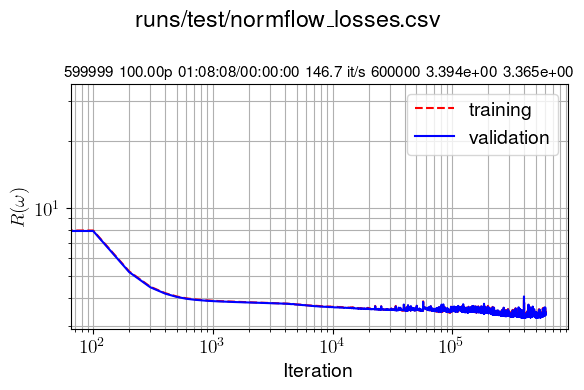

In [43]:
TRAIN = True

if TRAIN:
    train(objective, optimizer, scheduler,
          train_loader, train_loader_val, val_loader,
          config)
    
    monitor = mon.Monitor(config('file/losses'))
    monitor.plot()

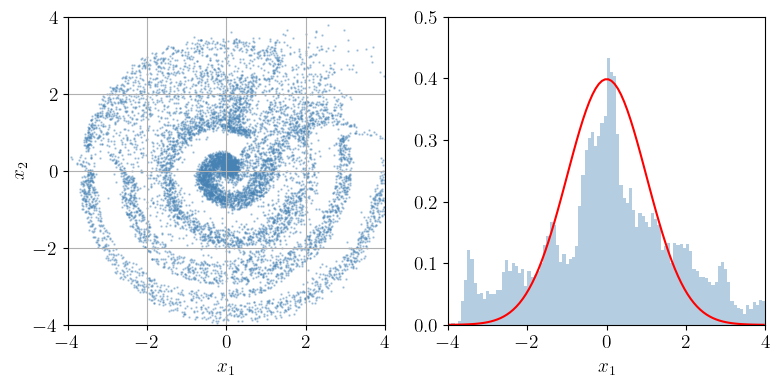

ValueError: too many values to unpack (expected 2)

In [44]:
model.load(config('file/params'))

K = 10000
y = model.sample(K)

x = model.inverse(y).detach().cpu().numpy()
plot_data(x, filename='normal2spiral.png')

test_X = next(iter(test_loader))
Y, _ = model(test_X)
Y = Y.detach().cpu().numpy()
plot_data(Y, filename='spiral2normal.png')